In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

In [123]:
dataset = pd.read_csv("/Bank Customer Churn Prediction.csv")

In [124]:
dataset.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [125]:
dataset.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [126]:
dataset.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [127]:
dataset[["credit_score", "age","tenure", "balance", "products_number", "estimated_salary"]].describe()

,credit_score,age,tenure,balance,products_number,estimated_salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


In [128]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [129]:
dataset["churn"].value_counts()

,count
churn,
0,7963
1,2037


In [130]:
data = dataset.copy()
data = data.drop(columns='customer_id')

X = data.drop(columns='churn')
y = data['churn']

categorical=["country", "gender"]
numerical=["credit_score", "age", "tenure", "balance", "products_number", "estimated_salary"]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical),
    ('cat', OneHotEncoder(drop='first'), categorical)
], remainder='passthrough')

In [131]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state=42,
    stratify = y)
print("Train size: ", X_train.shape)
print("Test size: ", X_test.shape)

Train size:  (8000, 10)
Test size:  (2000, 10)


RANDOM FOREST + SMOTE

In [132]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

rf_smote = ImbPipeline([('preprocessing', preprocessor),
                    ('smote', SMOTE(random_state=42)),
                  ('classifier', RandomForestClassifier(
                      n_estimators=200,
                      random_state=42
                  ))])

rf_smote.fit(X_train, Y_train)
y_pred_rf = rf_smote.predict(X_test)

print(classification_report(Y_test, y_pred_rf))
print(confusion_matrix(Y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91      1593
           1       0.65      0.56      0.60       407

    accuracy                           0.85      2000
   macro avg       0.77      0.74      0.75      2000
weighted avg       0.84      0.85      0.84      2000

[[1468  125]
 [ 179  228]]


In [133]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators' : [100, 200],
    'classifier__max_depth' : [5, 10, None],
    'classifier__min_samples_split' : [2, 5],
    'classifier__min_samples_leaf' : [1, 2, 4]
}

grid = GridSearchCV(rf_smote,
                    param_grid,
                    cv=5,
                    scoring='f1',
                    n_jobs=-1)

grid.fit(X_train, Y_train)
best_model = grid.best_estimator_
y_scores_rf = best_model.predict_proba(X_test)[:,1]



In [134]:
precision, recall, thresholds = precision_recall_curve(Y_test, y_scores_rf)
f1_scores_rf = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores_rf)]

print("Best thresholds: ", best_threshold)

Best thresholds:  0.46431204769978984


In [135]:
y_pred_new_rf = (y_scores_rf > best_threshold).astype(int)
print(classification_report(Y_test, y_pred_new_rf))
print(confusion_matrix(Y_test, y_pred_new_rf))


              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1593
           1       0.57      0.70      0.63       407

    accuracy                           0.83      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000

[[1382  211]
 [ 123  284]]


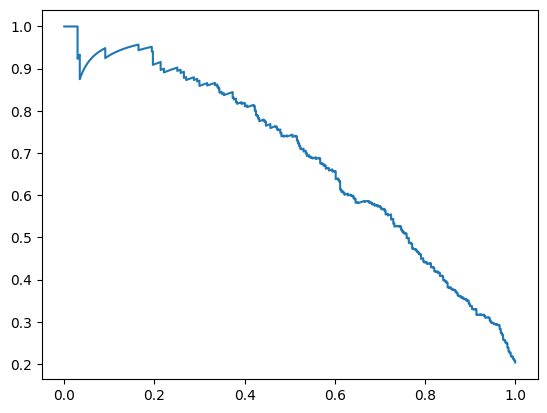

PR-AUC: 0.6882867202116573


In [136]:
precision, recall, thresholds = precision_recall_curve(Y_test, y_scores_rf)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f'PR AUC={pr_auc:.2f}')
plt.show()
print("PR-AUC:", pr_auc)

XGBOOST + SMOTE

In [137]:
from xgboost import XGBClassifier

xgb_smote = ImbPipeline([
('preprocessing', preprocessor),
('smote', SMOTE(random_state=42)),
('classifier', XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
))
])
xgb_smote.fit(X_train, Y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:11:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['credit_score', 'age',
                                                   'tenure', 'balance',
                                                   'products_number',
                                                   'estimated_salary']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['country', 'gender'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbac...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [138]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__subsample': [0.7, 1],
}

grid = GridSearchCV(
    xgb_smote,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, Y_train)
best_model = grid.best_estimator_

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:12:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.91      0.89      0.90      1593
           1       0.61      0.65      0.63       407

    accuracy                           0.84      2000
   macro avg       0.76      0.77      0.77      2000
weighted avg       0.85      0.84      0.85      2000

[[1423  170]
 [ 141  266]]


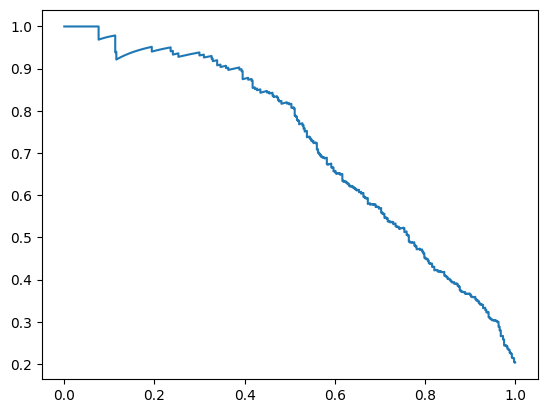

PR-AUC: 0.718689537625128


In [142]:
y_pred_xgb = best_model.predict(X_test)
y_scores_xgb = best_model.predict_proba(X_test)[:,1]

print(classification_report(Y_test, y_pred_xgb))
print(confusion_matrix(Y_test, y_pred_xgb))

# PR-AUC
precision, recall, _ = precision_recall_curve(Y_test, y_scores_xgb)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f'PR AUC={pr_auc:.2f}')
plt.show()
print("PR-AUC:", pr_auc)

In [140]:
f1_scores_xgb = 2 * (precision * recall) / (precision + recall)
best_index = np.argmax(f1_scores_xgb[:-1])
best_threshold = _[best_index]

print("Best threshold:", best_threshold)

y_pred_new_xgb = (y_scores_xgb > 0.45).astype(int)
print(classification_report(Y_test, y_pred_new_xgb))
print(confusion_matrix(Y_test, y_pred_new_xgb))

Best threshold: 0.49114326
              precision    recall  f1-score   support

           0       0.92      0.87      0.89      1593
           1       0.57      0.70      0.63       407

    accuracy                           0.83      2000
   macro avg       0.75      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000

[[1381  212]
 [ 123  284]]


ENSEMBLE MODEL: RF + XGBOOST

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1593
           1       0.64      0.60      0.62       407

    accuracy                           0.85      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.85      0.85      0.85      2000

[[1455  138]
 [ 161  246]]


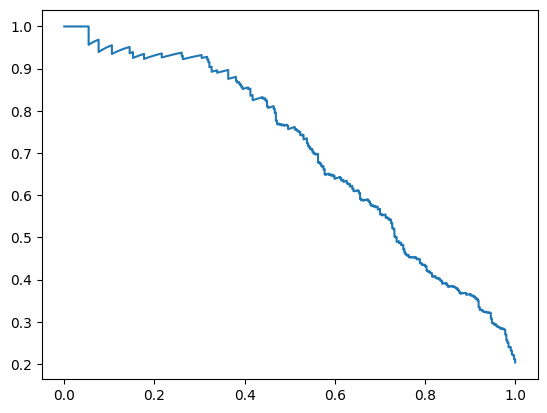

PR-AUC: 0.7038414700289808


In [143]:
y_scores_rf = rf_smote.predict_proba(X_test)[:,1]
y_scores_xgb = xgb_smote.predict_proba(X_test)[:,1]

y_prob_ensemble = 0.5*y_scores_rf + 0.5*y_scores_xgb

threshold = 0.45 # Can be adjusted based on business goal
y_pred_ensemble = (y_prob_ensemble > threshold).astype(int)


print(classification_report(Y_test, y_pred_ensemble))
print(confusion_matrix(Y_test, y_pred_ensemble))

precision, recall, _ = precision_recall_curve(Y_test, y_prob_ensemble)
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f'PR AUC={pr_auc:.2f}')
plt.show()
print("PR-AUC:", pr_auc)